# 00 · Data, universe and known limitations

Before judging any model we document what it is being judged on. Everything below is read
straight from the DuckDB tables built by `sv/universe.py`, `sv/ingest.py` and `sql/queries/build_panel.sql`.

Two limitations are **not fixable with free data** and are therefore carried into the report as
conditions on every conclusion:

1. **Survivorship bias** – the universe is a snapshot of today's listings; delisted companies are absent.
2. **Liquidity** – micro-caps produce spectacular but untradeable backtests, so a price / dollar-volume filter is applied and the *filtered* universe is what every model is scored on.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import config
from sv import db

con = db.connect(read_only=True)
q   = lambda name, **p: db.run_sql_file(con, name, p or None)   # run sql/queries/<name>.sql
sql = lambda text, **p: db.read(con, text, p or None)                # run an inline query
pd.set_option("display.width", 140); plt.rcParams["figure.figsize"] = (10, 4)

## Universe snapshot

In [2]:
sql("""SELECT COUNT(*) AS tickers, MIN(asof_date) AS asof, MIN(market_cap)/1e6 AS min_mcap_musd,
              MEDIAN(market_cap)/1e9 AS median_mcap_busd, MAX(market_cap)/1e12 AS max_mcap_tusd FROM universe""")

,tickers,asof,min_mcap_musd,median_mcap_busd,max_mcap_tusd
0,3000,2026-09-15,609.632128,4.231797,5.123269


## Price history coverage

In [3]:
sql("""SELECT COUNT(*) AS rows, COUNT(DISTINCT ticker) AS tickers, MIN(date) AS first_date, MAX(date) AS last_date,
              ROUND(COUNT(*) * 1.0 / COUNT(DISTINCT ticker)) AS avg_days_per_ticker FROM prices""")

,rows,tickers,first_date,last_date,avg_days_per_ticker
0,8104194,3001,2013-01-02,2026-09-14,2700.0


## Data quality: impossible prices

Yahoo returns zero or *negative* adjusted closes for a handful of names (a known artefact of its
dividend adjustment on tiny historical prices). They are kept in `prices` as received and excluded at
the panel / feature layer (`WHERE close > 0 AND adj_close > 0`).

In [4]:
sql("""SELECT ticker, COUNT(*) AS bad_rows, MIN(date) AS first_bad, MAX(date) AS last_bad, MIN(adj_close) AS min_adj_close
       FROM prices WHERE adj_close <= 0 OR close <= 0 GROUP BY ticker ORDER BY bad_rows DESC""")

,ticker,bad_rows,first_bad,last_bad,min_adj_close
0,CBIO,2189,2014-01-10,2022-09-20,-2788.500000
1,NFE,988,2019-01-31,2022-12-30,-23.594337
2,DEC,732,2021-01-04,2023-11-29,0.000000


## Survivorship footprint

`sql/queries/universe_coverage.sql` counts how many of *today's* tickers exist in each past year.
The upward slope is the bias: in 2015 only ~half of today's universe was listed, and none of the
companies that failed between 2015 and today are in the sample at all.

In [5]:
cov = q("universe_coverage"); cov

,year,with_prices,tradable_any_week,tradable_share,median_adv_musd
0,2015,2006,1572,0.678,15.674432
1,2016,2058,1641,0.676,15.488129
2,2017,2125,1723,0.706,17.872345
3,2018,2220,1836,0.724,20.401205
4,2019,2304,1890,0.709,19.074759
5,2020,2442,2063,0.720,21.358667
6,2021,2646,2282,0.758,24.573208
7,2022,2692,2257,0.732,22.175631
8,2023,2743,2291,0.731,21.799843
9,2024,2809,2438,0.765,26.739472


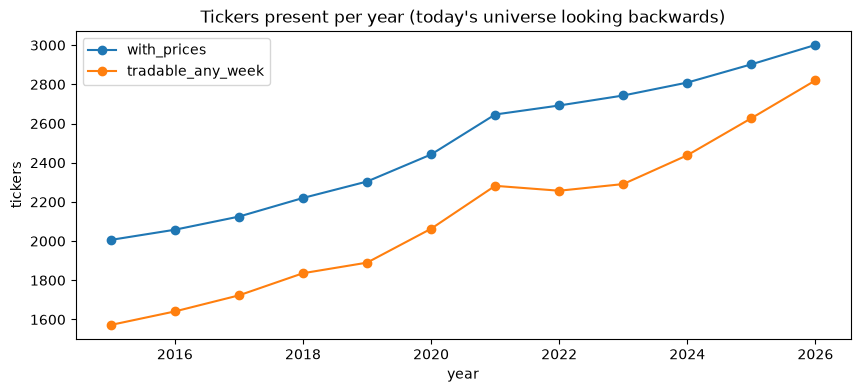

In [6]:
ax = cov.plot(x="year", y=["with_prices", "tradable_any_week"], marker="o")
ax.set_title("Tickers present per year (today's universe looking backwards)"); ax.set_ylabel("tickers"); plt.show()

## Liquidity filter

`tradable = close >= $5 AND 20-day average dollar volume >= $5M`. About a quarter of ticker-weeks fail it.
Anything a model does *outside* this set is out of scope for approval (report §Prohibited use).

In [7]:
sql("""SELECT EXTRACT(year FROM date) AS year,
              ROUND(AVG(tradable::INT), 3) AS tradable_share,
              ROUND(AVG(CASE WHEN close < $p THEN 1 ELSE 0 END), 3) AS fails_price,
              ROUND(AVG(CASE WHEN adv20_usd < $v THEN 1 ELSE 0 END), 3) AS fails_adv
       FROM panel GROUP BY 1 ORDER BY 1""", p=config.MIN_PRICE, v=config.MIN_ADV_USD)

,year,tradable_share,fails_price,fails_adv
0,2015,0.678,0.048,0.307
1,2016,0.676,0.053,0.309
2,2017,0.706,0.043,0.281
3,2018,0.724,0.044,0.263
4,2019,0.709,0.054,0.274
5,2020,0.720,0.070,0.253
6,2021,0.758,0.036,0.223
7,2022,0.732,0.067,0.243
8,2023,0.731,0.074,0.244
9,2024,0.765,0.068,0.207


## Rebalance calendar sanity check

In [8]:
d = sql("SELECT DISTINCT date FROM panel ORDER BY date")["date"]
print(len(d), "rebalance dates;", d.dt.day_name().value_counts().to_dict())
print("median gap (days):", d.diff().dt.days.median())

612 rebalance dates; {'Friday': 589, 'Thursday': 22, 'Monday': 1}
median gap (days): 7.0
